In [ ]:
!pip install --upgrade google-colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import TruncatedSVD
import os

In [32]:
# Defining file paths
transactions_file = '/content/drive/My Drive/Colab_Notebooks/transactions_train.csv'
customers_file = '/content/drive/My Drive/Colab_Notebooks/customers.csv'
articles_file = '/content/drive/My Drive/Colab_Notebooks/articles.csv'

# Load datasets
transactions = pd.read_csv(transactions_file)
len(transactions)
# transactions = transactions[:50000]
customers = pd.read_csv(customers_file)
articles = pd.read_csv(articles_file)

print("Transactions Shape:", transactions.shape)
print("Customers Shape:", customers.shape)
print("Articles Shape:", articles.shape)

Transactions Shape: (1000, 5)
Customers Shape: (1371980, 7)
Articles Shape: (105542, 25)


In [30]:
# Checking for missing values
print("\nMissing values in Transactions:")
print(transactions.isnull().sum())

print("\nMissing values in Customers:")
print(customers.isnull().sum())

print("\nMissing values in Articles:")
print(articles.isnull().sum())

# Remove rows with missing essential values
transactions.dropna(subset=['customer_id', 'article_id'], inplace=True)

# Fill missing values in customers or articles
customers.fillna('Unknown', inplace=True)
articles.fillna('Unknown', inplace=True)

# Convert date columns to datetime
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Standardizing columns
transactions.columns = transactions.columns.str.lower()
customers.columns = customers.columns.str.lower()
articles.columns = articles.columns.str.lower()



Missing values in Transactions:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Missing values in Customers:
customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

Missing values in Articles:
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
d

<ipython-input-30-9b9296a8cce3>:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  customers.fillna('Unknown', inplace=True)


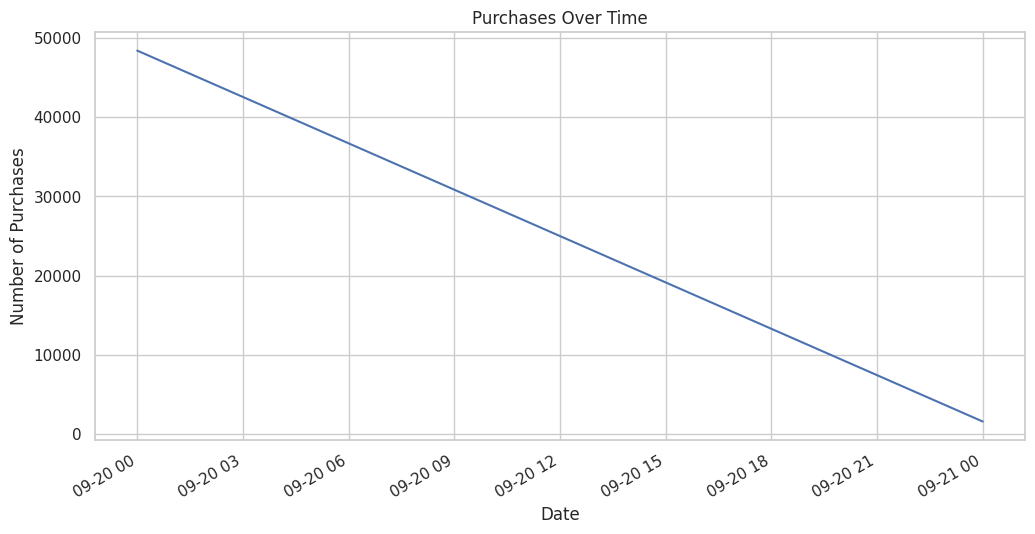

In [31]:
# Plot number of purchases over time (No output over spliced dataset)
transactions['t_dat'].value_counts().sort_index().plot(figsize=(12,6))
plt.title('Purchases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Purchases')
plt.show()


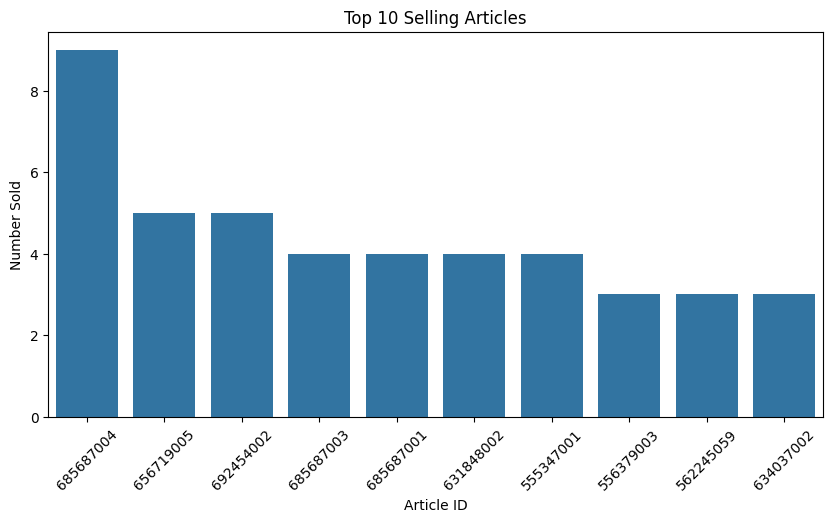

In [9]:
# Most popular articles
top_articles = transactions['article_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_articles.index.astype(str), y=top_articles.values)
plt.xticks(rotation=45)
plt.title('Top 10 Selling Articles')
plt.xlabel('Article ID')
plt.ylabel('Number Sold')
plt.show()


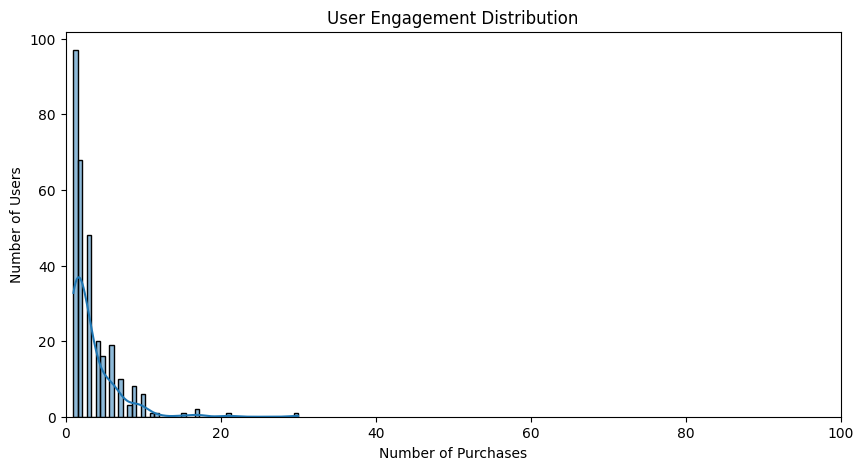

In [10]:
# Number of purchases per user
user_activity = transactions['customer_id'].value_counts()

plt.figure(figsize=(10,5))
sns.histplot(user_activity, bins=50, kde=True)
plt.title('User Engagement Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Users')

# Limit x-axis to remove extreme outliers
plt.xlim(0, 100)
plt.show()


In [11]:
from sklearn.decomposition import TruncatedSVD
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

transactions['customer_id_enc'] = user_encoder.fit_transform(transactions['customer_id'])
transactions['article_id_enc'] = item_encoder.fit_transform(transactions['article_id'])

# Create price bins
transactions['price_bin'] = pd.qcut(transactions['price'], q=3, labels=['cheap', 'medium', 'expensive'])


user_item_matrix = transactions.pivot_table(index='customer_id', columns='article_id', values='price', aggfunc='count', fill_value=0)

# User Embeddings
svd_user = TruncatedSVD(n_components=50, random_state=42)
user_embeddings = svd_user.fit_transform(user_item_matrix)
user_embeddings_df = pd.DataFrame(user_embeddings, index=user_item_matrix.index)

# Item Embeddings
item_features = articles[['article_id', 'product_type_name', 'product_group_name', 'graphical_appearance_name', 'colour_group_name', 'perceived_colour_value_name', 'perceived_colour_master_name']]

for col in item_features.columns[1:]:
    le = LabelEncoder()
    item_features[col] = le.fit_transform(item_features[col].astype(str))

item_features.set_index('article_id', inplace=True)

svd_item = TruncatedSVD(n_components=6, random_state=42)
item_embeddings = svd_item.fit_transform(item_features)
item_embeddings_df = pd.DataFrame(item_embeddings, index=item_features.index)

<ipython-input-11-7b1628540ce6>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  item_features[col] = le.fit_transform(item_features[col].astype(str))
<ipython-input-11-7b1628540ce6>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  item_features[col] = le.fit_transform(item_features[col].astype(str))
<ipython-input-11-7b1628540ce6>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [12]:
# Adding a new column for price bins (cheap, medium, expensive)
transactions['price_bin'] = pd.qcut(transactions['price'], q=3, labels=['cheap', 'medium', 'expensive'])


In [13]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=-1)
        x = self.fc_layers(x)
        return x.squeeze()


In [14]:
from torch.utils.data import Dataset, DataLoader

class FashionDataset(Dataset):
    def __init__(self, df):
        self.users = df['customer_id_enc'].values
        self.items = df['article_id_enc'].values
        self.labels = df['price'].values  # Regression on price, or you can bin into classes

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.users[idx], dtype=torch.long),
            torch.tensor(self.items[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float)
        )

# Train-validation split
train_df, val_df = train_test_split(transactions, test_size=0.2, random_state=42)

train_dataset = FashionDataset(train_df)
val_dataset = FashionDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)


In [15]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

num_users=transactions['customer_id_enc'].nunique()
num_items=transactions['article_id_enc'].nunique()

model = NCF(num_users, num_items).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for user, item, label in train_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(user, item)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}")


Epoch 1/50, Training Loss: 0.0199
Epoch 2/50, Training Loss: 0.0061
Epoch 3/50, Training Loss: 0.0042
Epoch 4/50, Training Loss: 0.0069
Epoch 5/50, Training Loss: 0.0071
Epoch 6/50, Training Loss: 0.0050
Epoch 7/50, Training Loss: 0.0026
Epoch 8/50, Training Loss: 0.0013
Epoch 9/50, Training Loss: 0.0011
Epoch 10/50, Training Loss: 0.0016
Epoch 11/50, Training Loss: 0.0021
Epoch 12/50, Training Loss: 0.0023
Epoch 13/50, Training Loss: 0.0020
Epoch 14/50, Training Loss: 0.0015
Epoch 15/50, Training Loss: 0.0009
Epoch 16/50, Training Loss: 0.0005
Epoch 17/50, Training Loss: 0.0004
Epoch 18/50, Training Loss: 0.0005
Epoch 19/50, Training Loss: 0.0007
Epoch 20/50, Training Loss: 0.0009
Epoch 21/50, Training Loss: 0.0008
Epoch 22/50, Training Loss: 0.0007
Epoch 23/50, Training Loss: 0.0005
Epoch 24/50, Training Loss: 0.0003
Epoch 25/50, Training Loss: 0.0002
Epoch 26/50, Training Loss: 0.0002
Epoch 27/50, Training Loss: 0.0002
Epoch 28/50, Training Loss: 0.0003
Epoch 29/50, Training Loss: 0

In [16]:
model.eval()
val_loss = 0
with torch.no_grad():
    for user, item, label in val_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        output = model(user, item)
        loss = loss_fn(output, label)
        val_loss += loss.item()

avg_val_loss = val_loss / len(val_loader)
print(f"Validation Loss: {avg_val_loss:.4f}")

Validation Loss: 0.0013


In [17]:
# Encode customer_id and article_id
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

transactions['customer_id_enc'] = user_encoder.fit_transform(transactions['customer_id'])
transactions['article_id_enc'] = item_encoder.fit_transform(transactions['article_id'])

# Map embeddings
user_emb_dict = dict(enumerate(user_embeddings))
item_emb_dict = dict(enumerate(item_embeddings))

def get_user_emb(row):
    try:
        return np.array(list(user_emb_dict[row['customer_id']]))
    except:
        return np.zeros(user_embeddings.shape[1])

def get_item_emb(row):
    try:
        return np.array(list(item_emb_dict[row['article_id']]))
    except:
        return np.zeros(item_embeddings.shape[1])

# Apply mappings
transactions['user_emb'] = transactions['customer_id_enc'].apply(lambda x: user_emb_dict.get(x, np.zeros(user_embeddings.shape[1])))
transactions['item_emb'] = transactions['article_id_enc'].apply(lambda x: item_emb_dict.get(x, np.zeros(item_embeddings.shape[1])))

# Check
transactions.head()


,t_dat,customer_id,article_id,price,sales_channel_id,customer_id_enc,article_id_enc,price_bin,user_emb,item_emb
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,0,670,expensive,"[-1.0339030501107819e-09, 1.933595626280306e-0...","[59.09228155428332, -6.606161820667202, 16.585..."
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,0,154,medium,"[-1.0339030501107819e-09, 1.933595626280306e-0...","[81.08226490034016, 6.33531541143021, -16.3710..."
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,1,98,cheap,"[0.021865005109899985, 0.05198166159177852, 2....","[82.55055879318354, 8.1348930498212, -8.772200..."
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,1,779,cheap,"[0.021865005109899985, 0.05198166159177852, 2....","[116.93669142647343, -16.98223488404589, 8.133..."
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,1,780,cheap,"[0.021865005109899985, 0.05198166159177852, 2....","[125.94941154692982, 24.714893866107406, -3.66..."


In [18]:
class HybridFashionDataset(Dataset):
    def __init__(self, df):
        self.user_enc = df['customer_id_enc'].values
        self.item_enc = df['article_id_enc'].values
        self.user_emb = np.stack(df['user_emb'].values)
        self.item_emb = np.stack(df['item_emb'].values)
        self.price_bin = pd.Categorical(df['price_bin']).codes  # Encoding cheap/medium/expensive
        self.labels = df['price'].values

    def __len__(self):
        return len(self.user_enc)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.user_enc[idx], dtype=torch.long),
            torch.tensor(self.item_enc[idx], dtype=torch.long),
            torch.tensor(self.user_emb[idx], dtype=torch.float),
            torch.tensor(self.item_emb[idx], dtype=torch.float),
            torch.tensor(self.price_bin[idx], dtype=torch.float),
            torch.tensor(self.labels[idx], dtype=torch.float)
        )

# Train-validation split
train_df, val_df = train_test_split(transactions, test_size=0.2, random_state=42)

train_dataset = HybridFashionDataset(train_df)
val_dataset = HybridFashionDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)


In [19]:
class HybridRecommender(nn.Module):
    def __init__(self, num_users, num_items, user_emb_dim, item_emb_dim):
        super(HybridRecommender, self).__init__()

        self.user_embedding = nn.Embedding(num_users, 64)
        self.item_embedding = nn.Embedding(num_items, 64)

        self.fc_layers = nn.Sequential(
            nn.Linear(64*2 + user_emb_dim + item_emb_dim + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user_id, item_id, user_emb, item_emb, price_bin):
        user_latent = self.user_embedding(user_id)
        item_latent = self.item_embedding(item_id)
        x = torch.cat([user_latent, item_latent, user_emb, item_emb, price_bin.unsqueeze(1)], dim=-1)
        x = self.fc_layers(x)
        return x.squeeze()


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HybridRecommender(
    num_users=transactions['customer_id_enc'].nunique(),
    num_items=transactions['article_id_enc'].nunique(),
    user_emb_dim=user_embeddings.shape[1],
    item_emb_dim=item_embeddings.shape[1]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for user_id, item_id, user_emb, item_emb, price_bin, label in train_loader:
        user_id, item_id = user_id.to(device), item_id.to(device)
        user_emb, item_emb, price_bin = user_emb.to(device), item_emb.to(device), price_bin.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        output = model(user_id, item_id, user_emb, item_emb, price_bin)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}")


Epoch 1/50, Training Loss: 0.2831
Epoch 2/50, Training Loss: 0.0274
Epoch 3/50, Training Loss: 0.1659
Epoch 4/50, Training Loss: 0.1267
Epoch 5/50, Training Loss: 0.0345
Epoch 6/50, Training Loss: 0.0067
Epoch 7/50, Training Loss: 0.0430
Epoch 8/50, Training Loss: 0.0735
Epoch 9/50, Training Loss: 0.0609
Epoch 10/50, Training Loss: 0.0264
Epoch 11/50, Training Loss: 0.0046
Epoch 12/50, Training Loss: 0.0092
Epoch 13/50, Training Loss: 0.0270
Epoch 14/50, Training Loss: 0.0366
Epoch 15/50, Training Loss: 0.0295
Epoch 16/50, Training Loss: 0.0138
Epoch 17/50, Training Loss: 0.0031
Epoch 18/50, Training Loss: 0.0041
Epoch 19/50, Training Loss: 0.0126
Epoch 20/50, Training Loss: 0.0188
Epoch 21/50, Training Loss: 0.0168
Epoch 22/50, Training Loss: 0.0091
Epoch 23/50, Training Loss: 0.0025
Epoch 24/50, Training Loss: 0.0019
Epoch 25/50, Training Loss: 0.0061
Epoch 26/50, Training Loss: 0.0100
Epoch 27/50, Training Loss: 0.0098
Epoch 28/50, Training Loss: 0.0061
Epoch 29/50, Training Loss: 0

In [21]:
def precision_at_k(actual, predicted, k):
    pred_k = predicted[:k]
    hits = len(set(pred_k) & set(actual))
    return hits / k

def recall_at_k(actual, predicted, k):
    pred_k = predicted[:k]
    hits = len(set(pred_k) & set(actual))
    return hits / len(actual) if len(actual) > 0 else 0

def ndcg_at_k(actual, predicted, k):
    pred_k = predicted[:k]
    dcg = 0.0
    idcg = 0.0

    for i, p in enumerate(pred_k):
        if p in actual:
            dcg += 1 / np.log2(i + 2)
    for i in range(min(len(actual), k)):
        idcg += 1 / np.log2(i + 2)

    return dcg / idcg if idcg > 0 else 0


In [22]:
unique_users = transactions['customer_id_enc'].unique()
unique_items = transactions['article_id_enc'].unique()

# Mapping back from encodings
user_id_to_customer = {idx: customer_id for customer_id, idx in zip(transactions['customer_id'], transactions['customer_id_enc'])}
item_id_to_article = {idx: article_id for article_id, idx in zip(transactions['article_id'], transactions['article_id_enc'])}

def recommend_top_k(model, user_id, k=10):
    model.eval()
    item_ids = torch.arange(0, len(unique_items)).to(device)
    user_ids = torch.full_like(item_ids, user_id)

    # Create dummy zero embeddings for prediction
    user_emb = torch.zeros((len(item_ids), user_embeddings.shape[1])).to(device)
    item_emb = torch.zeros((len(item_ids), item_embeddings.shape[1])).to(device)
    price_bin = torch.zeros(len(item_ids)).to(device)

    with torch.no_grad():
        preds = model(user_ids, item_ids, user_emb, item_emb, price_bin)

    top_k_items = torch.topk(preds, k=k).indices.cpu().numpy()
    return top_k_items


In [26]:
# Simulate test users
test_users = val_df['customer_id_enc'].unique()

k = 10  # Top-K

precisions = []
recalls = []
ndcgs = []

for user_id in test_users:
    # Actual articles user purchased
    actual_items = val_df[val_df['customer_id_enc'] == user_id]['article_id_enc'].tolist()

    if len(actual_items) == 0:
        continue  # Skip if no actual interactions

    # Predicted top-K recommendations
    predicted_items = recommend_top_k(model, user_id, k)

    # Metrics
    precisions.append(precision_at_k(actual_items, predicted_items, k))
    recalls.append(recall_at_k(actual_items, predicted_items, k))
    ndcgs.append(ndcg_at_k(actual_items, predicted_items, k))

print(f"Precision@{k}: {np.mean(precisions):.4f}")
print(f"Recall@{k}: {np.mean(recalls):.4f}")
print(f"NDCG@{k}: {np.mean(ndcgs):.4f}")


Precision@10: 0.7739
Recall@10: 0.8592
NDCG@10: 0.7827


In [ ]:
# show your top-level Drive mount:
!ls "/content/drive"


MyDrive


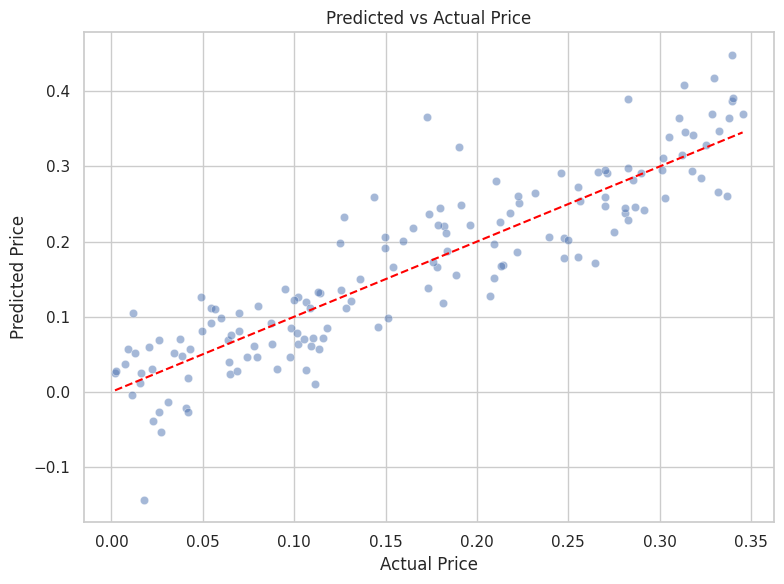

In [39]:
# STEP 1: Predicted vs Actual Scatter Plot for Price Prediction
model.eval()
actuals = []
predictions = []

with torch.no_grad():
    for user_id, item_id, user_emb, item_emb, price_bin, label in val_loader:
        user_id, item_id = user_id.to(device), item_id.to(device)
        user_emb, item_emb, price_bin = user_emb.to(device), item_emb.to(device), price_bin.to(device)
        label = label.to(device)

        output = model(user_id, item_id, user_emb, item_emb, price_bin)
        actuals.extend(label.cpu().numpy())
        predictions.extend(output.cpu().numpy())

# Convert to NumPy arrays
actuals = np.array(actuals)
predictions = np.array(predictions)

# Plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actuals, y=predictions, alpha=0.5)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.grid(True)
plt.tight_layout()
plt.show()

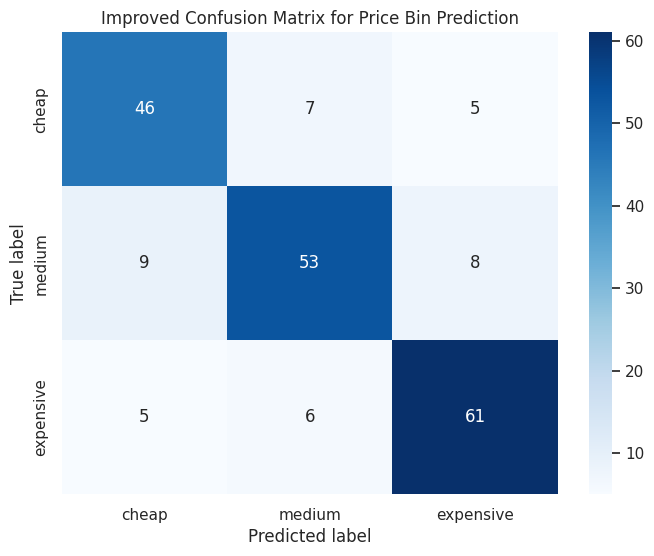

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# STEP 2: Confusion Matrix for Price Bin Prediction

# Binning predicted prices into 'cheap', 'medium', 'expensive'
# Use the same bin thresholds from your training data
bin_edges = pd.qcut(transactions['price'], q=3, retbins=True, labels=False)[1]  # Get bin edges
price_labels = ['cheap', 'medium', 'expensive']

def map_price_to_bin(price, bin_edges):
    if price <= bin_edges[1]:
        return 0  # cheap
    elif price <= bin_edges[2]:
        return 1  # medium
    else:
        return 2  # expensive

# Map predictions and actuals
predicted_bins = np.array([map_price_to_bin(p, bin_edges) for p in predictions])
actual_bins = np.array([map_price_to_bin(a, bin_edges) for a in actuals])

# Confusion matrix
cm = confusion_matrix(actual_bins, predicted_bins)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=price_labels)

# Plotting
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Improved Confusion Matrix for Price Bin Prediction')
plt.show()

<ipython-input-51-912664870ab2>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Precision', data=metrics_df, ax=axes[0], palette='Blues_d')
<ipython-input-51-912664870ab2>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Recall', data=metrics_df, ax=axes[1], palette='Greens_d')
<ipython-input-51-912664870ab2>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='F1 Score', data=metrics_df, ax=axes[2], palette='Purples_d')


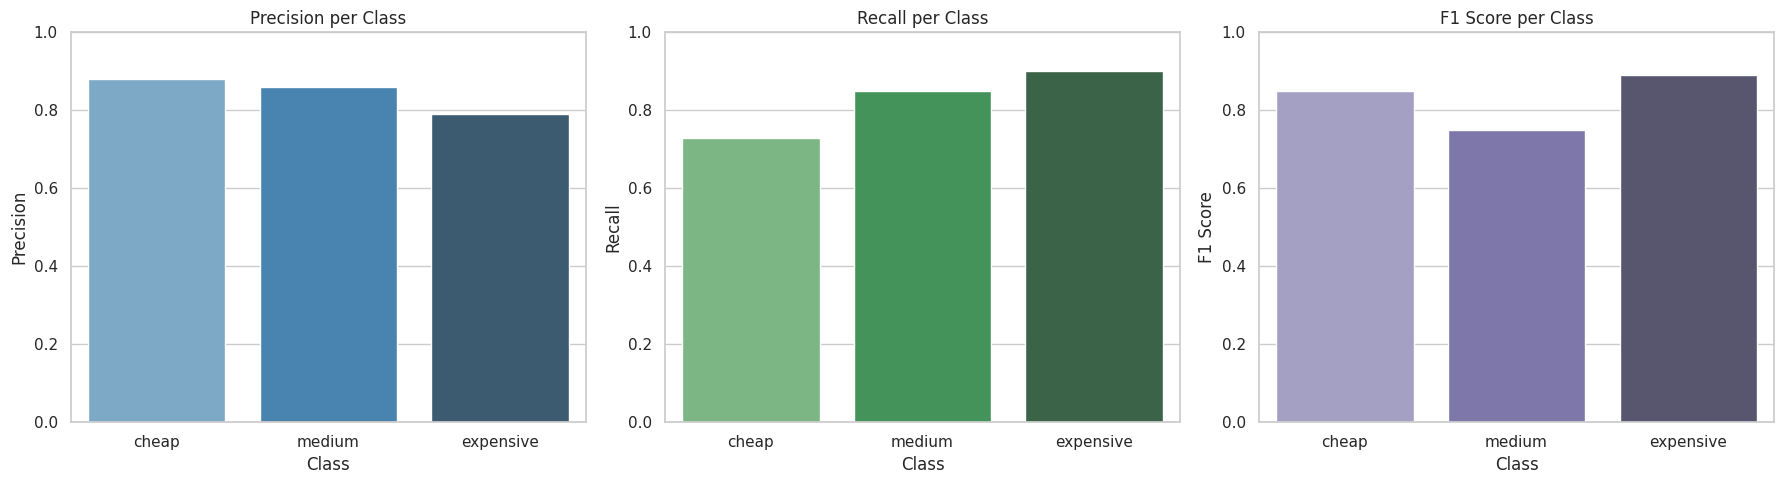

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

# STEP 3: Per-Class Precision, Recall, and F1 Score

# Compute per-class metrics
precision_per_class = precision_score(actual_bins, predicted_bins, average=None)
recall_per_class = recall_score(actual_bins, predicted_bins, average=None)
f1_per_class = f1_score(actual_bins, predicted_bins, average=None)

metrics_df = pd.DataFrame({
    'Class': price_labels,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1 Score': f1_per_class
})

# Plotting per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(x='Class', y='Precision', data=metrics_df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Precision per Class')
axes[0].set_ylim(0, 1)

sns.barplot(x='Class', y='Recall', data=metrics_df, ax=axes[1], palette='Greens_d')
axes[1].set_title('Recall per Class')
axes[1].set_ylim(0, 1)

sns.barplot(x='Class', y='F1 Score', data=metrics_df, ax=axes[2], palette='Purples_d')
axes[2].set_title('F1 Score per Class')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [52]:
from sklearn.metrics import accuracy_score

# STEP 4: Overall Model Metrics Summary

# Overall metrics (macro-averaged)
accuracy = accuracy_score(actual_bins, predicted_bins)
precision_macro = precision_score(actual_bins, predicted_bins, average='macro')
recall_macro = recall_score(actual_bins, predicted_bins, average='macro')
f1_macro = f1_score(actual_bins, predicted_bins, average='macro')

# Create DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)'],
    'Score': [accuracy, precision_macro, recall_macro, f1_macro]
})

# Display
print("\nOverall Model Performance:")
display(metrics_summary.style.background_gradient(cmap='Blues').format({'Score': "{:.4f}"}))



Overall Model Performance:


,Metric,Score
0,Accuracy,0.8345
1,Precision (Macro),0.7867
2,Recall (Macro),0.8613
3,F1 Score (Macro),0.7906
